**Loading Dataset initially**

In [1]:
df <- read.csv("GlobalYouTubeStatistics_Cleaned.csv")
head(df)

,rank,youtuber,subscribers,video_views,category,uploads,country_of_origin,abbreviation,channel_type,video_views_rank,⋯,log_avg_yearly_earnings,earnings_outlier,is_inactive,norm_subscribers,norm_video_views,norm_uploads,norm_video_views_rank,norm_country_rank,norm_channel_type_rank,earnings_consistent
,<int>,<chr>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,⋯,<dbl>,<lgl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
1,1,T-Series,245000000,228000000000,Music,20082,India,IN,Music,1,⋯,17.8690331,TRUE,FALSE,1.0000,1.0000,0.0666,0.0000,0.0000,0.0000,FALSE
2,2,YouTube Movies,170000000,0,Film & Animation,1,United States,US,Games,4055159,⋯,0.2700271,FALSE,TRUE,0.6777,0.0000,0.0000,0.9993,0.9908,0.9589,TRUE
3,3,MrBeast,166000000,28368841870,Entertainment,741,United States,US,Entertainment,48,⋯,17.3521126,TRUE,FALSE,0.6605,0.1244,0.0025,0.0000,0.0000,0.0000,FALSE
4,4,Cocomelon - Nursery Rhymes,162000000,164000000000,Education,966,United States,US,Education,2,⋯,17.7345092,TRUE,FALSE,0.6433,0.7193,0.0032,0.0000,0.0001,0.0000,FALSE
5,5,SET India,159000000,148000000000,Shows,116536,India,IN,Entertainment,3,⋯,17.6549629,TRUE,FALSE,0.6304,0.6491,0.3868,0.0000,0.0001,0.0001,FALSE
6,6,Music,119000000,0,Entertainment,0,United States,US,Music,4057944,⋯,0.0000000,FALSE,TRUE,0.4585,0.0000,0.0000,1.0000,0.0063,0.0083,TRUE


Raw rows before Preprocessing

In [28]:
df_raw1 <- read.csv("GlobalYouTubeStatistics.csv")
nrow(df_raw1)

[1] 1006

Cleaned Rows

In [29]:
df_raw <- read.csv("GlobalYouTubeStatistics_Cleaned.csv")
nrow(df_raw)

[1] 978

Original Columns

In [30]:
ncol(df_raw1)

[1] 29

Final Columns (After Feature Engineering)

In [32]:
ncol(df_raw)

[1] 46

Total Channels

In [33]:
total_channels <- nrow(df)
total_channels

[1] 978

Average Subscribers

In [34]:
avg_subscribers <- mean(df$subscribers, na.rm=TRUE)
avg_subscribers

[1] 23123313

Average Yearly Earnings

In [35]:
avg_yearly <- mean(df$avg_yearly_earnings, na.rm=TRUE)
avg_yearly

[1] 3802884

Average Video Views

In [36]:
avg_views <- mean(df$video_views, na.rm=TRUE)
avg_views

[1] 11124638904

Average Channel Age

In [38]:
avg_age <- mean(df$channel_age_years, na.rm=TRUE)
avg_age

[1] 13.05402

2. Top 10 Channels by Subscribers

In [2]:
top10 <- df[order(-df$subscribers), ]
head(top10[, c("youtuber","subscribers")], 10)

,youtuber,subscribers
,<chr>,<int>
1,T-Series,245000000
2,YouTube Movies,170000000
3,MrBeast,166000000
4,Cocomelon - Nursery Rhymes,162000000
5,SET India,159000000
6,Music,119000000
7,Kids Diana Show,112000000
8,PewDiePie,111000000
9,Like Nastya,106000000


3. Category with Highest Average Subscribers

In [3]:
aggregate(subscribers ~ category, data=df, mean)

category,subscribers
<chr>,<dbl>
Autos & Vehicles,17850000
Comedy,20123188
Education,26713636
Entertainment,22393993
Film & Animation,27406667
Gaming,20982796
Howto & Style,19636842
Movies,25650000
Music,25838500


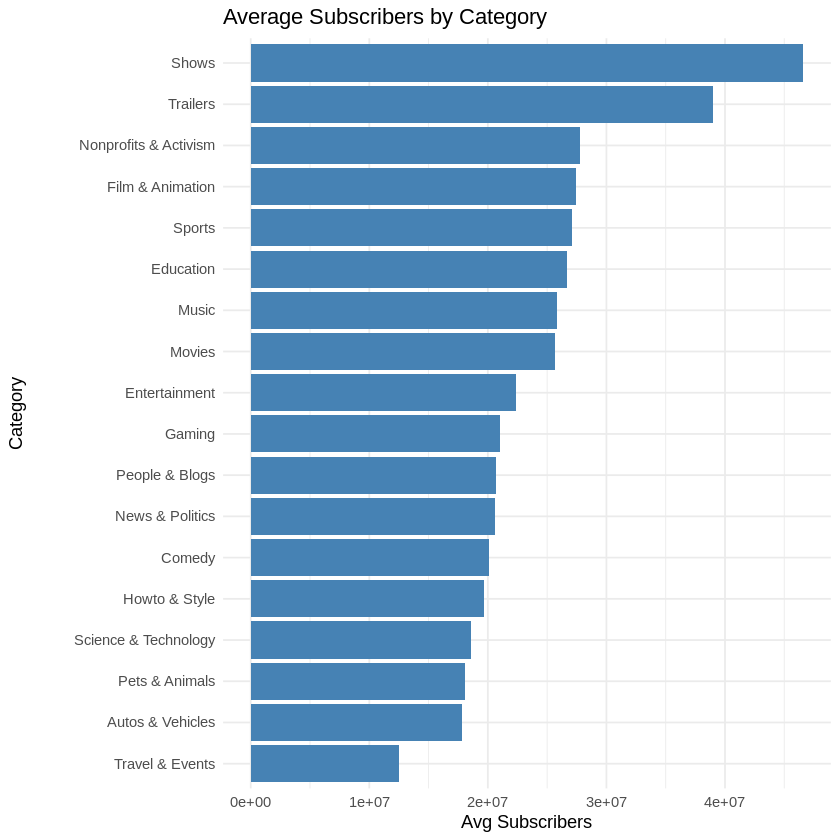

In [44]:
library(ggplot2)

agg <- aggregate(subscribers ~ category, data=df, mean)

ggplot(agg, aes(x=reorder(category, subscribers), y=subscribers)) +
  geom_bar(stat="identity", fill="steelblue") +
  coord_flip() +
  labs(title="Average Subscribers by Category",
       x="Category",
       y="Avg Subscribers") +
  theme_minimal()

4. Average Uploads per Category

In [4]:
aggregate(uploads ~ category, data=df, mean)

category,uploads
<chr>,<dbl>
Autos & Vehicles,1898.500
Comedy,1119.754
Education,3212.932
Entertainment,10274.936
Film & Animation,2861.844
Gaming,4336.032
Howto & Style,1682.737
Movies,3553.000
Music,2358.025


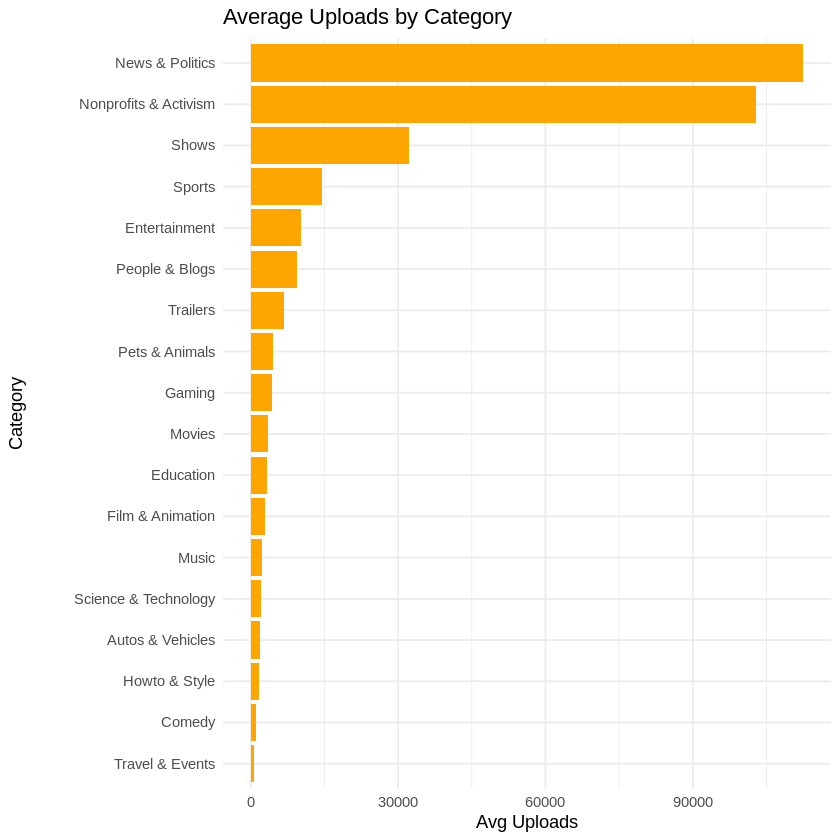

In [46]:
agg <- aggregate(uploads ~ category, data=df, mean)
agg <- agg[order(-agg$uploads), ]

library(ggplot2)

ggplot(agg, aes(x=reorder(category, uploads), y=uploads)) +
  geom_bar(stat="identity", fill="orange") +
  coord_flip() +
  labs(title="Average Uploads by Category",
       x="Category",
       y="Avg Uploads") +
  theme_minimal()

5. Top 5 Countries with Highest Channels

In [79]:
head(sort(table(df$country_of_origin), decreasing=TRUE), 10)


 United States          India         Brazil United Kingdom         Mexico 
           429            168             62             43             33 
     Indonesia          Spain       Thailand         Canada    South Korea 
            28             22             18             15             15 

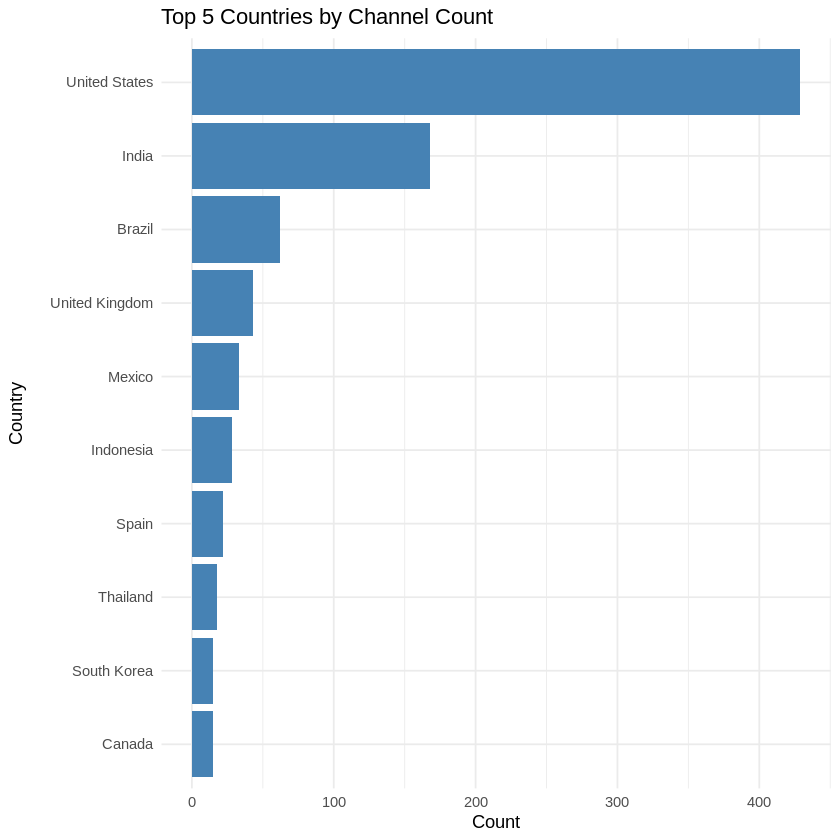

In [80]:
library(ggplot2)

top5 <- sort(table(df$country_of_origin), decreasing=TRUE)[1:10]
top5_df <- as.data.frame(top5)

ggplot(top5_df, aes(x=reorder(Var1, Freq), y=Freq)) +
  geom_bar(stat="identity", fill="steelblue") +
  coord_flip() +
  labs(title="Top 5 Countries by Channel Count",
       x="Country",
       y="Count") +
  theme_minimal()

6. Distribution of Channel Types

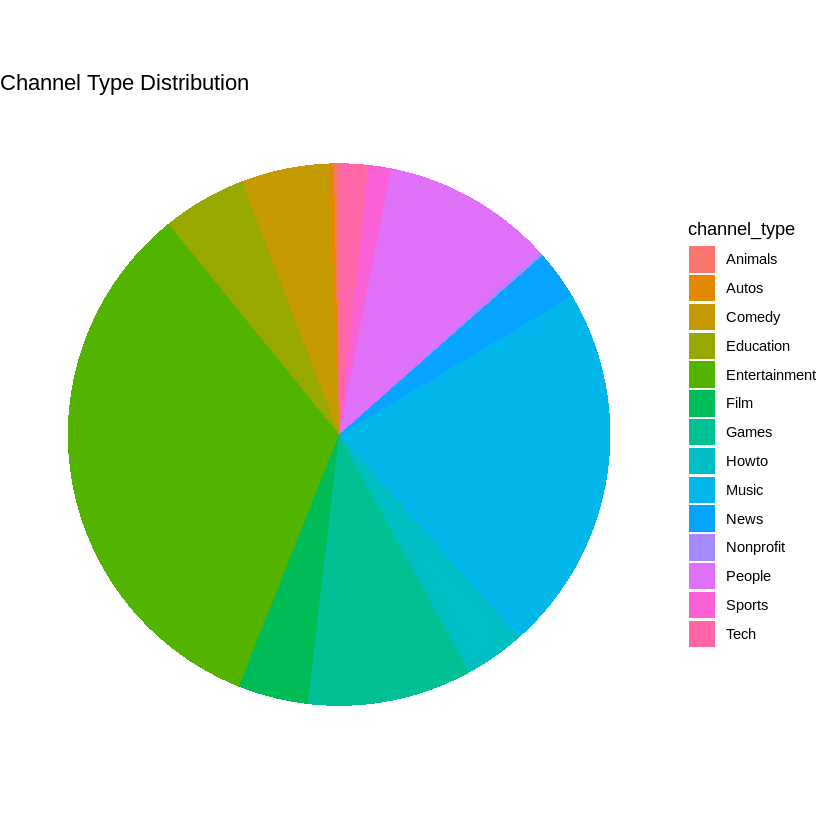

In [42]:
library(ggplot2)

ggplot(df, aes(x="", fill=channel_type)) +
  geom_bar(width=1) +
  coord_polar("y") +
  theme_void() +
  labs(title="Channel Type Distribution")

7. Correlation: Subscribers vs Views

[1] 0.7506854

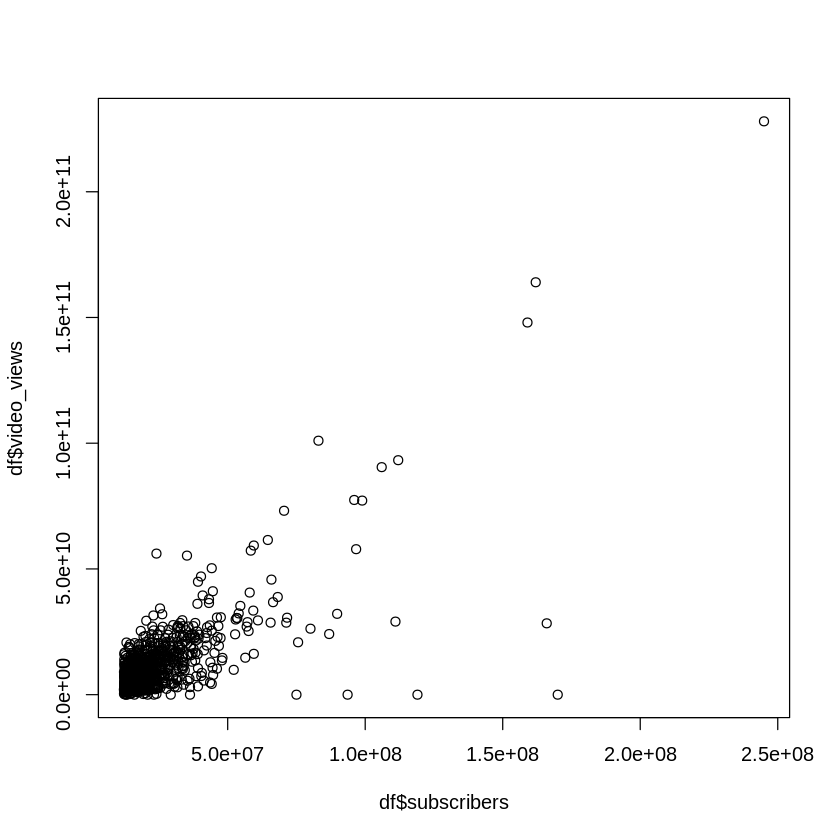

In [7]:
cor(df$subscribers, df$video_views)

plot(df$subscribers, df$video_views)

8. Monthly Earnings Variation Across Categories

In [8]:
aggregate(avg_monthly_earnings ~ category, data=df, mean)

category,avg_monthly_earnings
<chr>,<dbl>
Autos & Vehicles,577325.0
Comedy,355089.9
Education,376625.1
Entertainment,368339.6
Film & Animation,397893.3
Gaming,142544.4
Howto & Style,102356.0
Movies,241550.0
Music,295428.7


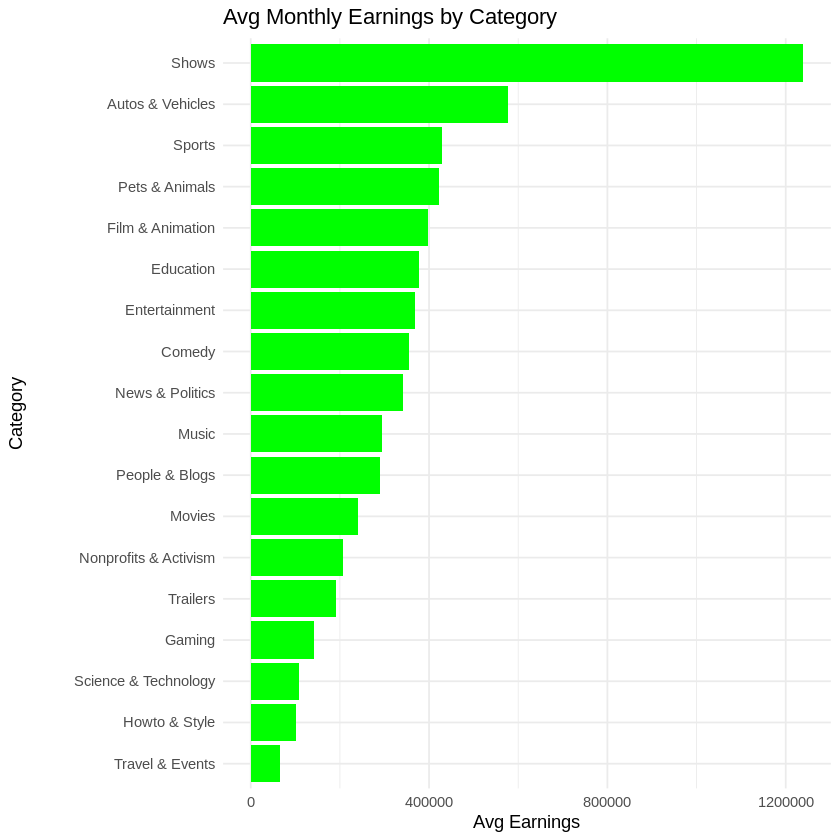

In [45]:
agg <- aggregate(avg_monthly_earnings ~ category, data=df, mean)
agg <- agg[order(-agg$avg_monthly_earnings), ]

ggplot(agg, aes(x=reorder(category, avg_monthly_earnings), y=avg_monthly_earnings)) +
  geom_bar(stat="identity", fill="green") +
  coord_flip() +
  labs(title="Avg Monthly Earnings by Category",
       x="Category",
       y="Avg Earnings") +
  theme_minimal()

9. Subscriber Growth (Last 30 Days)

In [101]:
top10 <- df[order(-df$avg_monthly_sub_gain), ][1:10, ]

top10[, c("youtuber","avg_monthly_sub_gain")]

,youtuber,avg_monthly_sub_gain
,<chr>,<dbl>
17,5-Minute Crafts,1189840
10,Vlad and Niki,1047226
1,T-Series,1021855
3,MrBeast,985280
9,Like Nastya,871137
7,Kids Diana Show,862600
6,Music,796519
14,BLACKPINK,773072
2,YouTube Movies,702712


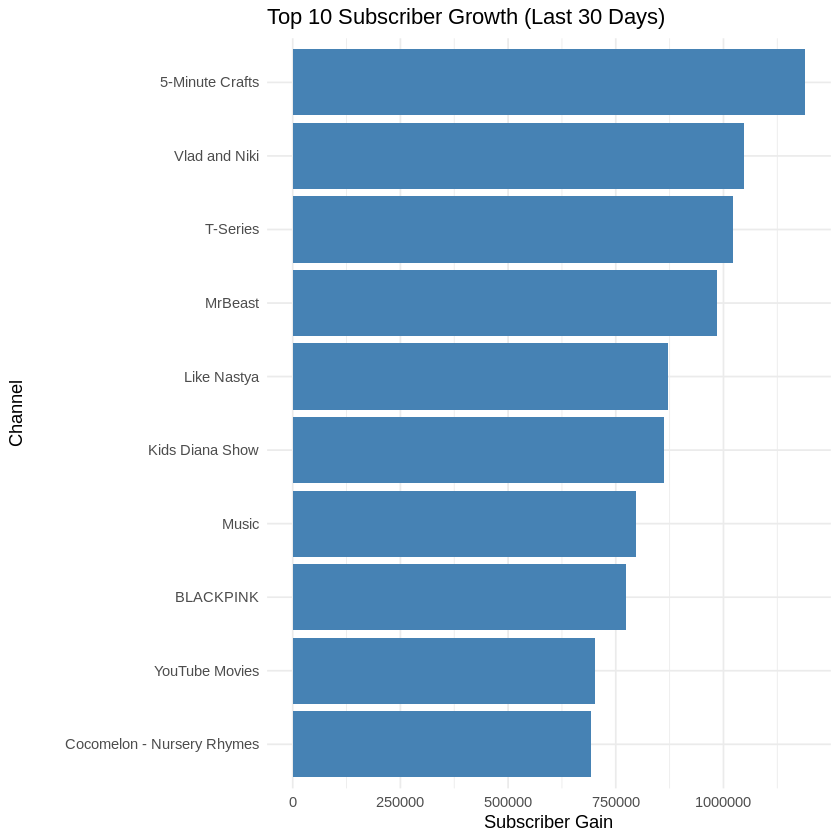

In [102]:
library(ggplot2)

ggplot(top10, aes(x=reorder(youtuber, avg_monthly_sub_gain), y=avg_monthly_sub_gain)) +
  geom_bar(stat="identity", fill="steelblue") +
  coord_flip() +
  labs(title="Top 10 Subscriber Growth (Last 30 Days)",
       x="Channel",
       y="Subscriber Gain") +
  theme_minimal()

10. Outliers in Yearly Earnings

In [115]:
Q1 <- quantile(df$avg_yearly_earnings, 0.25, na.rm=TRUE)
Q3 <- quantile(df$avg_yearly_earnings, 0.75, na.rm=TRUE)
IQR_val <- Q3 - Q1

upper_bound <- Q3 + 1.5 * IQR_val

outliers <- df[df$avg_yearly_earnings > upper_bound, ]

In [116]:
top_outliers <- outliers[order(-outliers$avg_yearly_earnings), ][1:10, ]

top_outliers[, c("youtuber","avg_yearly_earnings")]

,youtuber,avg_yearly_earnings
,<chr>,<dbl>
493,KIMPRO,86800000
417,DaFuq!?Boom!,58750000
1,T-Series,57600000
302,KL BRO Biju Rithvik,51850000
4,Cocomelon - Nursery Rhymes,50350000
5,SET India,46500000
22,Zee TV,43500000
140,StarPlus,42500000
16,Sony SAB,42300000


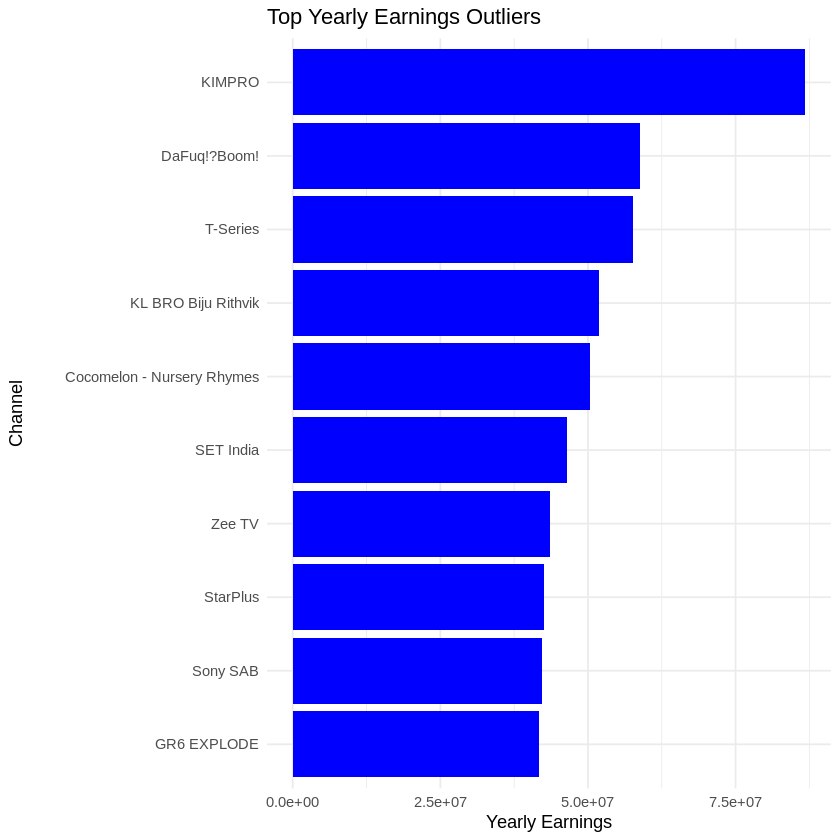

In [118]:
library(ggplot2)

ggplot(top_outliers, aes(x=reorder(youtuber, avg_yearly_earnings), y=avg_yearly_earnings)) +
  geom_bar(stat="identity", fill="blue") +
  coord_flip() +
  labs(title="Top Yearly Earnings Outliers",
       x="Channel",
       y="Yearly Earnings") +
  theme_minimal()

11. Distribution of Channel Creation Dates

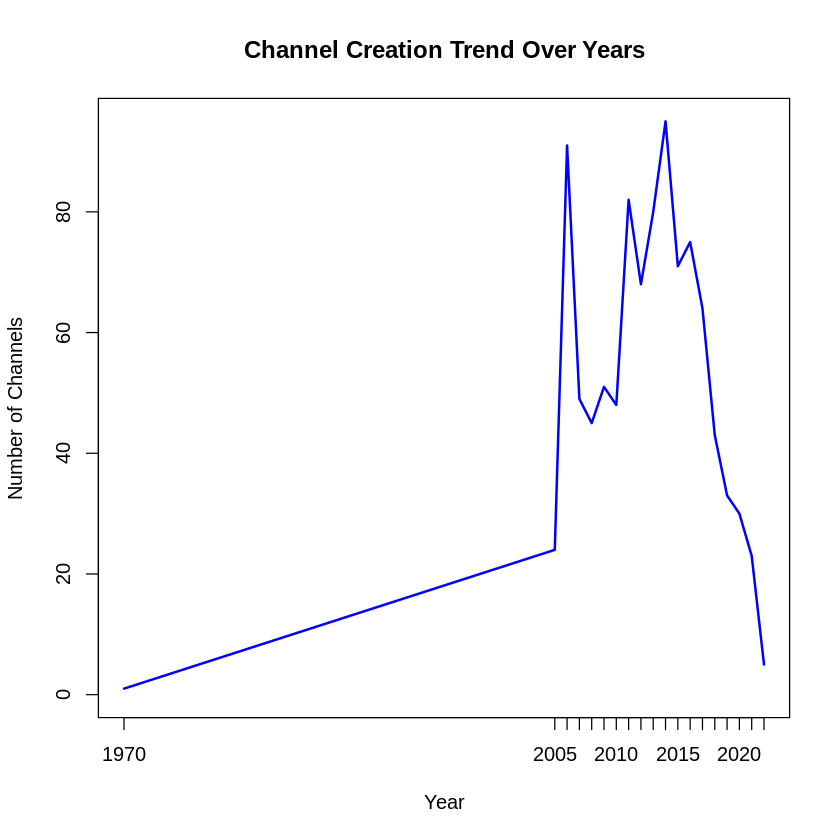

In [93]:
year_counts <- table(df$created_year)

plot(year_counts, type="l",
     main="Channel Creation Trend Over Years",
     xlab="Year",
     ylab="Number of Channels",
     col="blue", lwd=2)

12. Education Enrollment vs Channels

In [91]:
cor(df$gross_tertiary_education_enrollment, df$subscribers)

[1] -0.0001405981

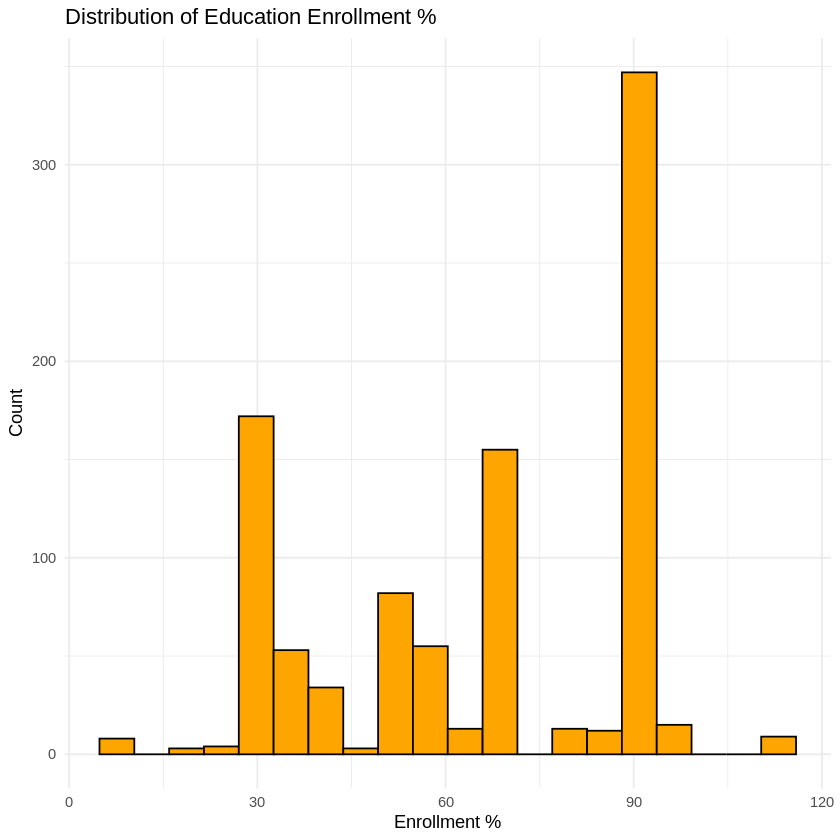

In [92]:
ggplot(df, aes(x=gross_tertiary_education_enrollment)) +
  geom_histogram(bins=20, fill="orange", color="black") +
  labs(title="Distribution of Education Enrollment %",
       x="Enrollment %",
       y="Count") +
  theme_minimal()

13. Unemployment Rate Comparison

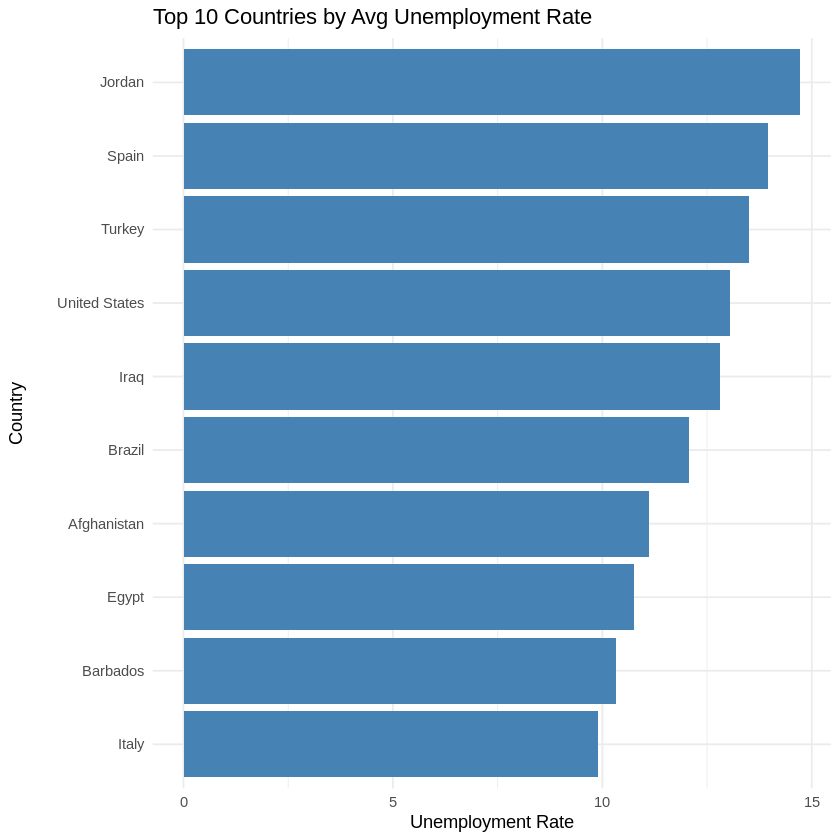

In [82]:
library(ggplot2)

agg <- aggregate(unemployment_rate ~ country_of_origin, data=df, mean)
top10 <- agg[order(-agg$unemployment_rate), ][1:10, ]

ggplot(top10, aes(x=reorder(country_of_origin, unemployment_rate), y=unemployment_rate)) +
  geom_bar(stat="identity", fill="steelblue") +
  coord_flip() +
  labs(title="Top 10 Countries by Avg Unemployment Rate",
       x="Country",
       y="Unemployment Rate") +
  theme_minimal()

14. Urban Population Percentage Average

In [69]:
df$urban_percent <- (df$urban_population / df$population) * 100

In [70]:
agg <- aggregate(urban_percent ~ country_of_origin, data=df, mean)

In [71]:
countries <- c("United States","India","Brazil","United Kingdom",
               "Mexico","Indonesia","Spain","Thailand","South Korea","Canada")

agg <- agg[agg$country_of_origin %in% countries, ]

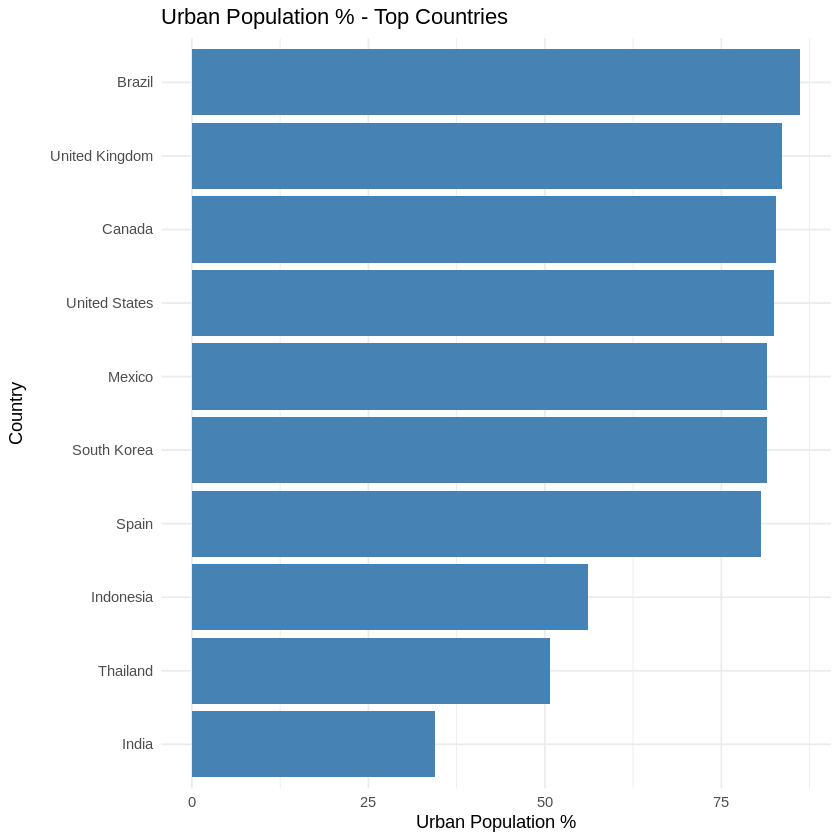

In [72]:
library(ggplot2)

ggplot(agg, aes(x=reorder(country_of_origin, urban_percent), y=urban_percent)) +
  geom_bar(stat="identity", fill="steelblue") +
  coord_flip() +
  labs(title="Urban Population % - Top Countries",
       x="Country",
       y="Urban Population %") +
  theme_minimal()

15. Geographic Distribution

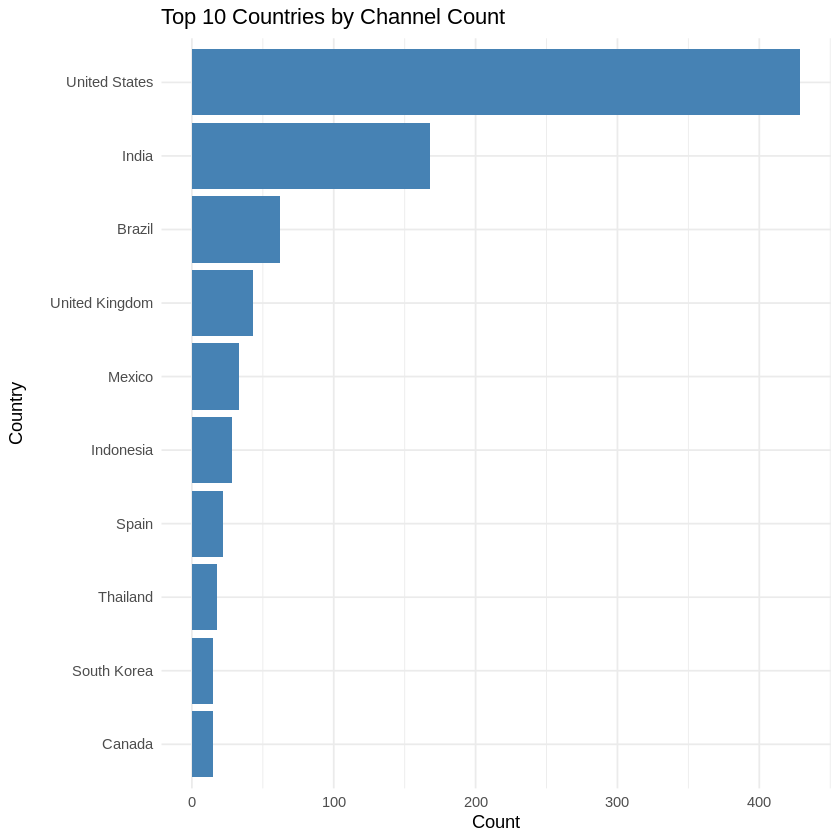

In [50]:
library(ggplot2)

top10 <- sort(table(df$country_of_origin), decreasing=TRUE)[1:10]
top10_df <- as.data.frame(top10)

ggplot(top10_df, aes(x=reorder(Var1, Freq), y=Freq)) +
  geom_bar(stat="identity", fill="steelblue") +
  coord_flip() +
  labs(title="Top 10 Countries by Channel Count",
       x="Country",
       y="Count") +
  theme_minimal()

Avg Subscribers by Country

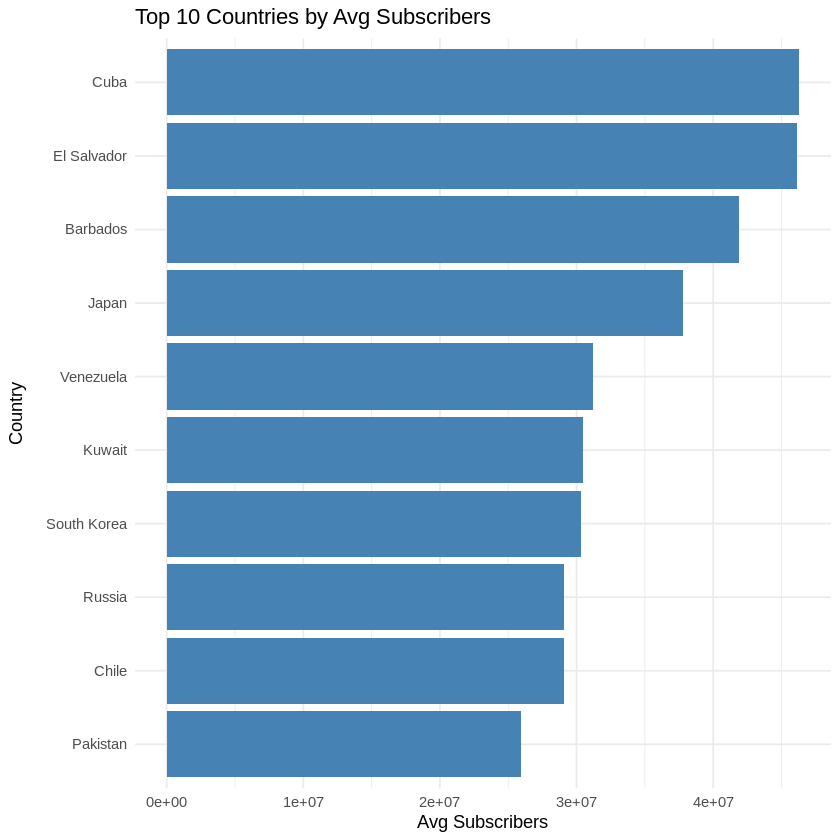

In [51]:
library(ggplot2)

agg <- aggregate(subscribers ~ country_of_origin, data=df, mean)
agg <- agg[order(-agg$subscribers), ][1:10, ]

ggplot(agg, aes(x=reorder(country_of_origin, subscribers), y=subscribers)) +
  geom_bar(stat="identity", fill="steelblue") +
  coord_flip() +
  labs(title="Top 10 Countries by Avg Subscribers",
       x="Country",
       y="Avg Subscribers") +
  theme_minimal()

16. Correlation: Subscribers vs Population

In [16]:
cor(df$subscribers, df$population)

[1] 0.07286456

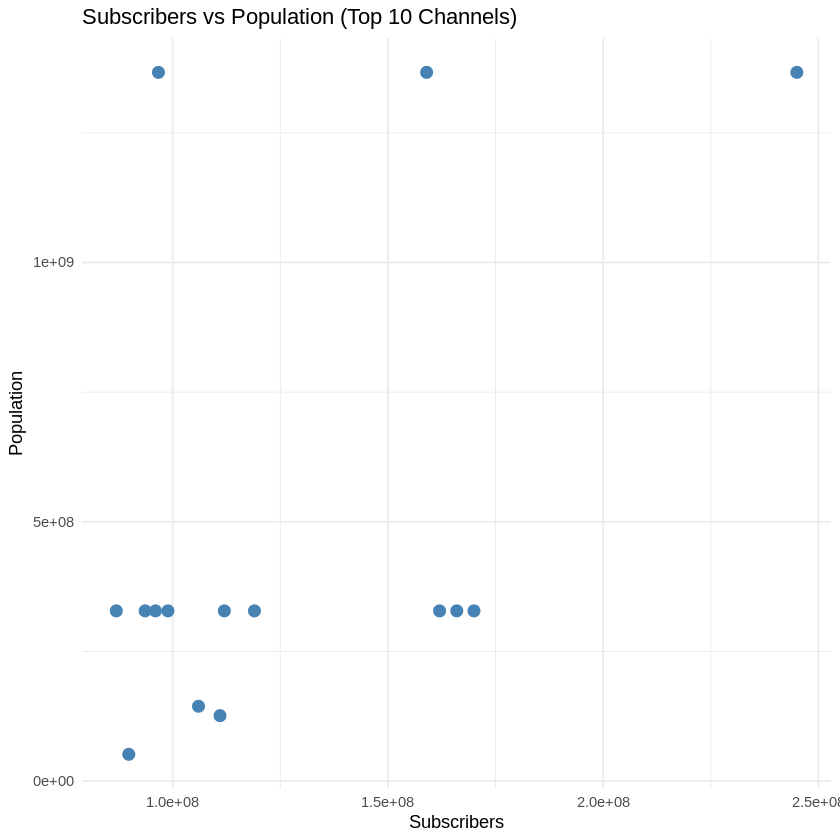

In [78]:
library(ggplot2)

top10 <- df[order(-df$subscribers), ][1:15, ]

ggplot(top10, aes(x=subscribers, y=population)) +
  geom_point(color="steelblue", size=3) +
  labs(title="Subscribers vs Population (Top 10 Channels)",
       x="Subscribers",
       y="Population") +
  theme_minimal()

17. Population Comparison of Top Countries

In [84]:
agg <- aggregate(population ~ country_of_origin, data=df, mean)
top10 <- agg[order(-agg$population), ][1:10, ]

top10

,country_of_origin,population
,<chr>,<dbl>
10,China,1397715000
19,India,1366417754
2,Andorra,328239523
47,United States,328239523
20,Indonesia,270203917
31,Pakistan,216565318
7,Brazil,212559417
5,Bangladesh,167310838
34,Russia,144373535


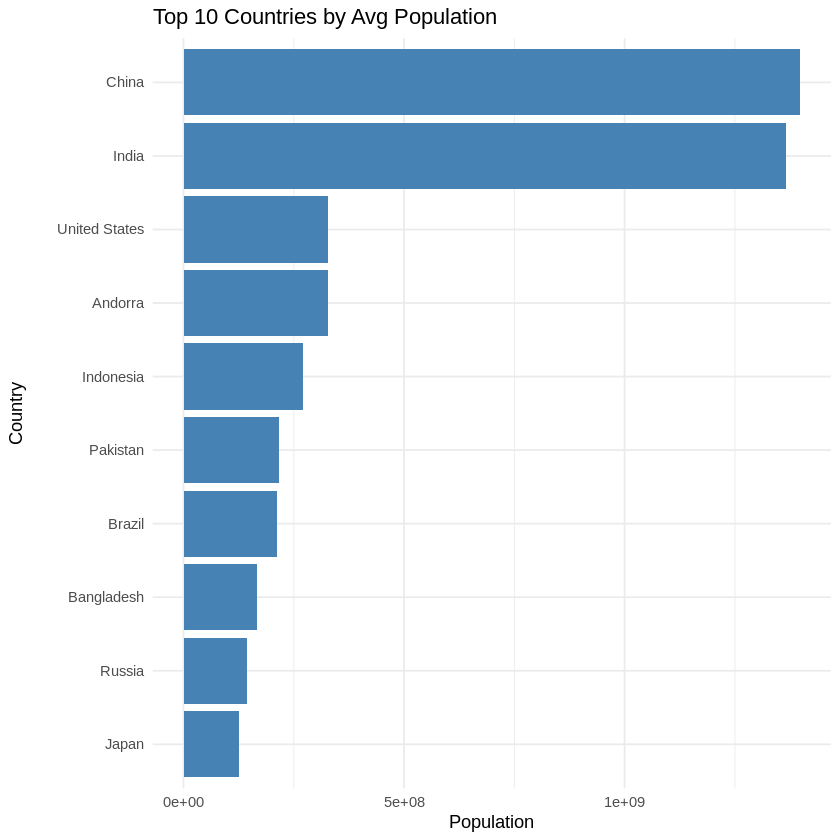

In [85]:
library(ggplot2)

ggplot(top10, aes(x=reorder(country_of_origin, population), y=population)) +
  geom_bar(stat="identity", fill="steelblue") +
  coord_flip() +
  labs(title="Top 10 Countries by Avg Population",
       x="Country",
       y="Population") +
  theme_minimal()

18. Subscribers Gained vs Unemployment

In [107]:
cor(df$avg_monthly_sub_gain, df$unemployment_rate, use="complete.obs")

[1] -0.05704505

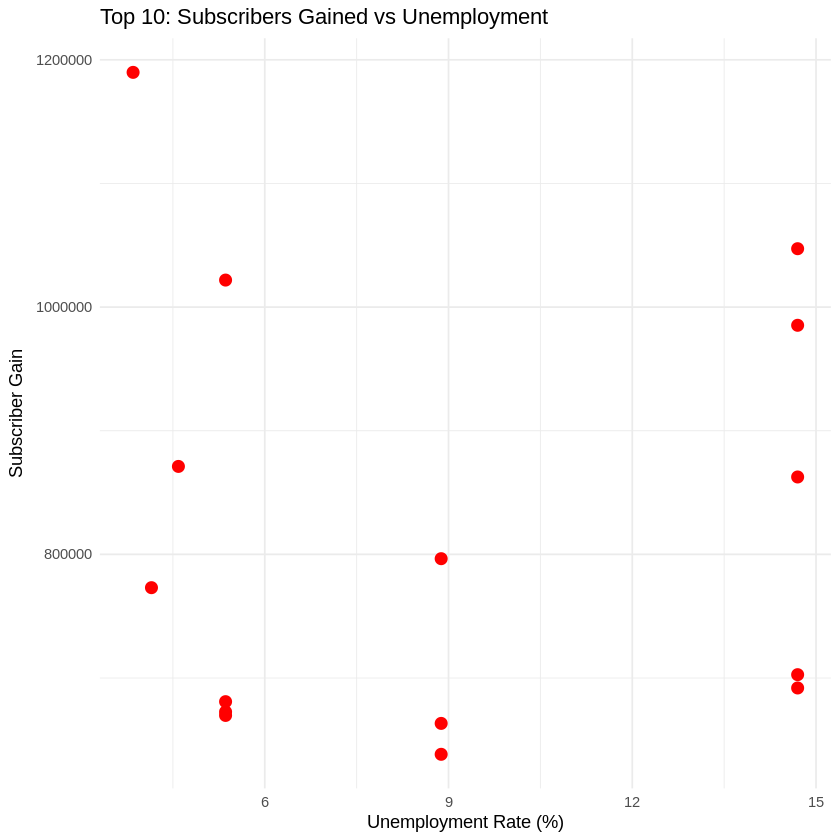

In [111]:
top10 <- df[order(-df$avg_monthly_sub_gain), ][1:15, ]

ggplot(top10, aes(x=unemployment_rate, y=avg_monthly_sub_gain)) +
  geom_point(color="red", size=3) +
  labs(title="Top 10: Subscribers Gained vs Unemployment",
       x="Unemployment Rate (%)",
       y="Subscriber Gain") +
  theme_minimal()

19. Video Views (Last 30 Days Distribution)

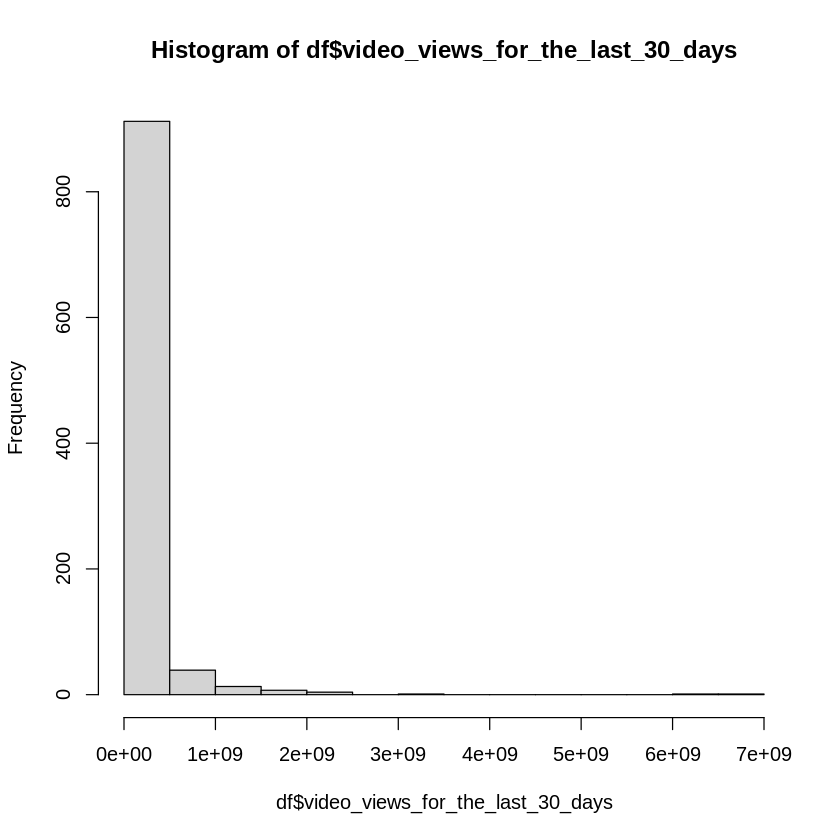

In [19]:
hist(df$video_views_for_the_last_30_days)

20. Seasonal Upload Trends

In [20]:
aggregate(uploads ~ created_month, data=df, mean)

created_month,uploads
<chr>,<dbl>
Apr,2499.930
Aug,16903.026
Dec,3678.667
Feb,11909.439
Jan,8023.560
Jul,5653.227
Jun,13409.192
Mar,4433.202
May,8096.395


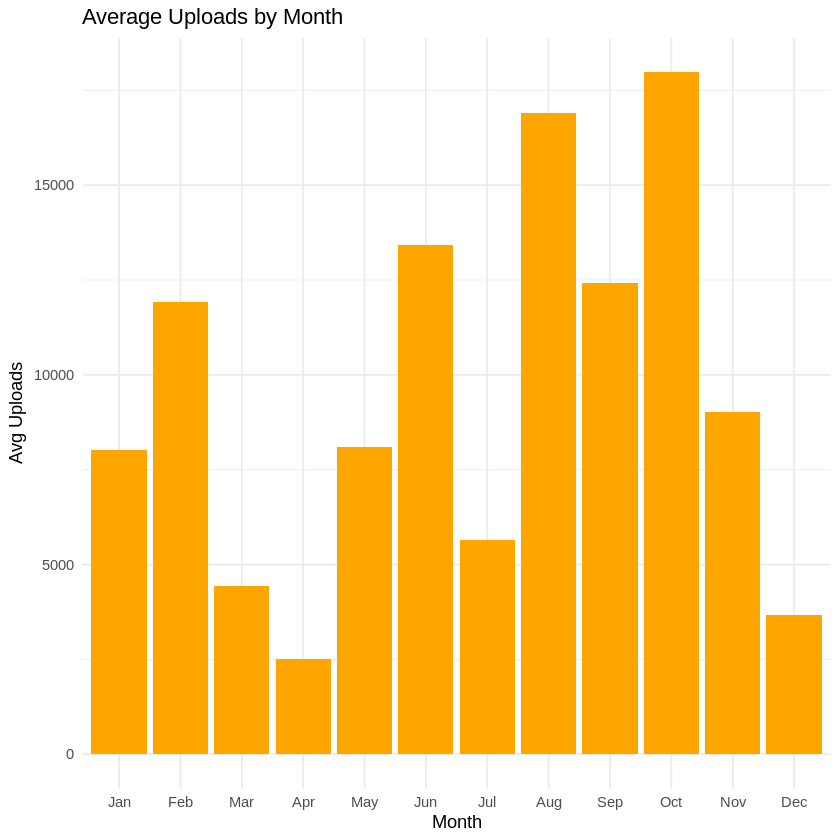

In [123]:
library(ggplot2)

agg <- aggregate(uploads ~ created_month, data=df, mean)

month_order <- c("Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec")

agg$created_month <- factor(agg$created_month, levels=month_order)

ggplot(agg, aes(x=created_month, y=uploads)) +
  geom_bar(stat="identity", fill="orange") +
  labs(title="Average Uploads by Month",
       x="Month",
       y="Avg Uploads") +
  theme_minimal()

21. Average Monthly Subscriber Gain Since Creation

In [104]:
top_gain <- df[order(-df$avg_monthly_sub_gain), ]
head(top_gain[, c("youtuber","avg_monthly_sub_gain")], 10)

,youtuber,avg_monthly_sub_gain
,<chr>,<dbl>
17,5-Minute Crafts,1189840
10,Vlad and Niki,1047226
1,T-Series,1021855
3,MrBeast,985280
9,Like Nastya,871137
7,Kids Diana Show,862600
6,Music,796519
14,BLACKPINK,773072
2,YouTube Movies,702712


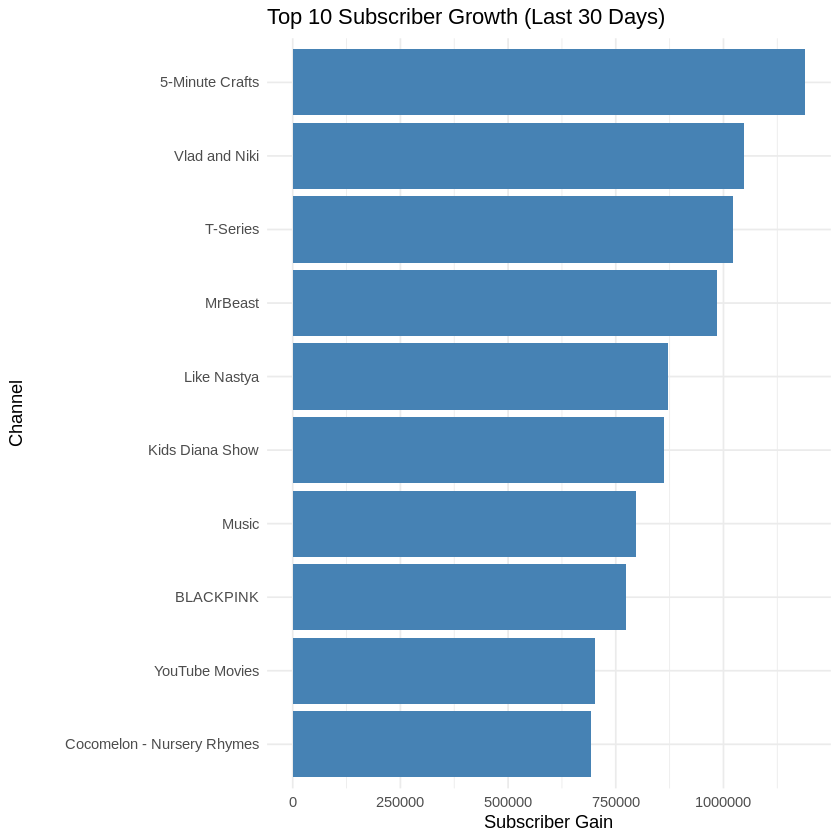

In [105]:
library(ggplot2)

top_gain <- df[order(-df$avg_monthly_sub_gain), ][1:10, ]

ggplot(top_gain, aes(x=reorder(youtuber, avg_monthly_sub_gain), y=avg_monthly_sub_gain)) +
  geom_bar(stat="identity", fill="steelblue") +
  coord_flip() +
  labs(title="Top 10 Subscriber Growth (Last 30 Days)",
       x="Channel",
       y="Subscriber Gain") +
  theme_minimal()

22. Channel count by Category

In [49]:
table(df$category)


     Autos & Vehicles                Comedy             Education 
                    2                    69                    44 
        Entertainment      Film & Animation                Gaming 
                  283                    45                    93 
        Howto & Style                Movies                 Music 
                   38                     2                   200 
      News & Politics Nonprofits & Activism        People & Blogs 
                   26                     2                   128 
       Pets & Animals  Science & Technology                 Shows 
                    4                    17                    11 
               Sports              Trailers       Travel & Events 
                   11                     2                     1 

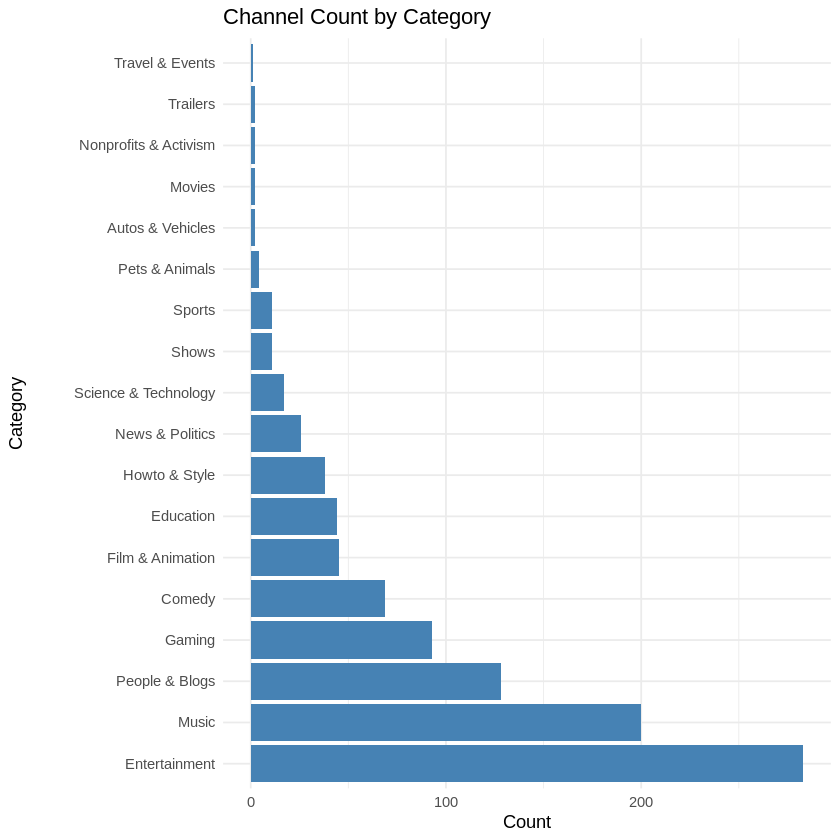

In [47]:
library(ggplot2)

ggplot(df, aes(x=reorder(category, category, function(x)-length(x)))) +
  geom_bar(fill="steelblue") +
  coord_flip() +
  labs(title="Channel Count by Category",
       x="Category",
       y="Count") +
  theme_minimal()